In [1]:
import matplotlib.pyplot as plt
import numpy as np

from superfv.tools.variable_index_map import VariableIndexMap
from superfv.configs import generate_fv_scheme_parameters, HydroParameters
from superfv import RiemannSolver
from superfv.mesh import UniformFiniteVolumeMesh
from superfv.finite_volume_driver import update_fv_fluxes
from superfv.bin._finite_volume_driver import update_fv_fluxes as update_fv_fluxes_cpp

p = 2
N = 32
ng = 2
gamma = 1.4
isothermal = False
iso_cs = 1.0

In [2]:
idx = VariableIndexMap(
    {"rho": 0, "vx": 1, "vy": 2, "vz": 3, "P": 4, "mx": 1, "my": 2, "mz": 3, "E": 4},
    group_var_map={
        "v": ["vx", "vy", "vz"],
        "m": ["mx", "my", "mz"],
        "primitives": ["rho", "v", "P"],
        "conservatives": ["rho", "m", "E"],
    },
)

fv_scheme = generate_fv_scheme_parameters("test", p)
hydro_params = HydroParameters(
    gamma=1.4, riemann_solver=RiemannSolver.HLLC, isothermal=isothermal, iso_cs=iso_cs, CFL=0.8
)

mesh = UniformFiniteVolumeMesh(
    (0.0, 1.0),
    (0.0, 1.0),
    (0.0, 1.0),
    N,
    N,
    N,
    ng,
    ("x", "y", "z"),
)

In [3]:
_q_ = np.zeros((idx.nvars, *mesh._shape_))

nvars = idx.nvars
nx, ny, nz = mesh.shape
_nx_, _ny_, _nz_ = mesh._shape_
X, Y, Z = mesh.Centers
interior = tuple([slice(ng, -ng) if n > 1 else slice(None) for n in mesh.shape])

_q_[idx("rho")] = 1.0
_q_[idx("rho")][interior] = np.where(
    np.logical_and(
        np.logical_and(np.abs(X - 0.5) < 0.25, np.abs(Y - 0.5) < 0.25), np.abs(Z - 0.5) < 0.25
    ),
    2.0,
    1.0,
)
_q_[idx("mx")] = 1.5
_q_[idx("E")] = 3.0

_F1_ = np.empty((nvars, nx + 1, _ny_, _nz_))
F2 = np.empty((nvars, nx + 1, ny, nz))
_G1_ = np.empty((nvars, _nx_, ny + 1, _nz_))
G2 = np.empty((nvars, nx, ny + 1, nz))
_H1_ = np.empty((nvars, _nx_, _ny_, nz + 1))
H2 = np.empty((nvars, nx, ny, nz + 1))

In [4]:
%%timeit
update_fv_fluxes(
    _q_,
    np.empty_like(_q_),
    _F1_,
    _G1_,
    _H1_,
    np.array([]),
    np.array([]),
    np.array([]),
    idx,
    mesh.active_dims,
    mesh,
    fv_scheme,
    hydro_params,
    0.0,
)

/Users/jonathan/Desktop/superfv/superfv/hydro.py:172: RuntimeWarning: invalid value encountered in divide
  vx = mx / rho
/Users/jonathan/Desktop/superfv/superfv/hydro.py:173: RuntimeWarning: invalid value encountered in divide
  vy = my / rho
/Users/jonathan/Desktop/superfv/superfv/hydro.py:174: RuntimeWarning: invalid value encountered in divide
  vz = mz / rho
/Users/jonathan/Desktop/superfv/superfv/hydro.py:172: RuntimeWarning: divide by zero encountered in divide
  vx = mx / rho
/Users/jonathan/Desktop/superfv/superfv/hydro.py:173: RuntimeWarning: divide by zero encountered in divide
  vy = my / rho
/Users/jonathan/Desktop/superfv/superfv/hydro.py:174: RuntimeWarning: divide by zero encountered in divide
  vz = mz / rho
/Users/jonathan/Desktop/superfv/superfv/hydro.py:175: RuntimeWarning: invalid value encountered in multiply
  KE = 0.5 * rho * (vx**2 + vy**2 + vz**2)
/Users/jonathan/Desktop/superfv/superfv/hydro.py:86: RuntimeWarning: invalid value encountered in multiply
  KE = 

32.9 ms ± 3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [5]:
%%timeit
update_fv_fluxes_cpp(
    _q_,
    F2,
    G2,
    H2,
    np.empty_like(_q_),
    fv_scheme.p,
    mesh.nghost,
    hydro_params.gamma,
    hydro_params.isothermal,
    hydro_params.iso_cs,
)

34.6 ms ± 198 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


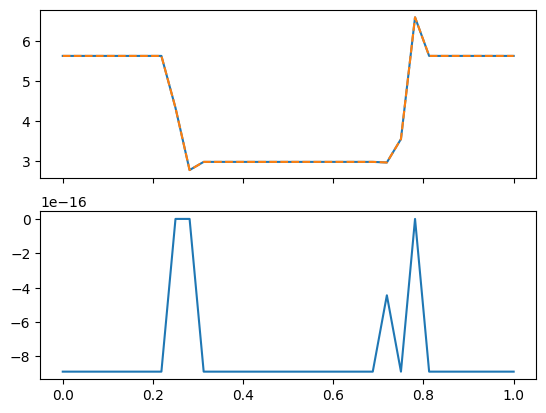

In [6]:
fig, ax = plt.subplots(2, 1, sharex=True)

F1_trace = _F1_[4, :, mesh._shape_[1] // 2, mesh._shape_[2] // 2]
F2_trace = F2[4, :, mesh.shape[1] // 2, mesh.shape[2] // 2]

ax[0].plot(mesh.faces[0], F1_trace)
ax[0].plot(mesh.faces[0], F2_trace, "--")
ax[1].plot(mesh.faces[0], F2_trace - F1_trace)